In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


# 분류모델 평가 함수
from sklearn.metrics import accuracy_score, f1_score 
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

# 1차 모델

In [2]:
filepath = "./B1_종합실습2_전처리데이터(SVM_NN).csv"
df_raw = pd.read_csv(filepath, encoding='utf-8')

In [3]:
df_raw_x = df_raw.drop("scale", axis = 1, inplace = False)
df_raw_y = df_raw["scale"] 

display("설명변수:", df_raw_x.head())
display("목표변수:",df_raw_y.tail())

'설명변수:'

,pt_thick,pt_width,hsb,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,rolling_temp,descaling_count,steel_kind_C,...,class_code_BV,class_code_CCS,class_code_Common,class_code_DNV,class_code_GL,class_code_JS,class_code_KR,class_code_KS,class_code_LR,class_code_NK
0,0.287834,1.757877,1,-0.623753,1.140313,-1.034166,-0.617721,-0.099397,2,0,...,0,0,0,0,0,0,0,0,0,0
1,0.287834,1.757877,1,-0.623753,1.368163,-0.918797,-0.909098,-0.052252,2,0,...,0,0,0,0,0,0,0,0,0,0
2,0.342996,1.555380,1,-1.330154,1.140313,-1.726379,-0.811972,-0.806566,2,0,...,0,0,0,1,0,0,0,0,0,0
3,0.342996,1.555380,1,-0.247005,1.482088,-1.380272,-0.180654,-0.869425,2,0,...,0,0,0,1,0,0,0,0,0,0
4,0.618805,0.542895,1,-0.812126,1.823863,-1.322588,-1.151913,-1.058004,2,0,...,1,0,0,0,0,0,0,0,0,0


'목표변수:'

995    0
996    0
997    0
998    0
999    0
Name: scale, dtype: int64

In [4]:
# 변환된 설명변수 데이터 사용:df_x_converted 
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y
                                    , test_size = 0.4, random_state = 1986)

print("분할된 Train Data: {}".format(df_train_x.shape))
print("분할된 Test Data: {}".format(df_test_x.shape))

분할된 Train Data: (600, 35)
분할된 Test Data: (400, 35)


In [5]:
svm_uncust = SVC(random_state=1986, probability=True)
svm_uncust.fit(df_train_x, df_train_y)

# train 모델 정확도
print("Train Accuracy : {:.3f}".format(svm_uncust.score(df_train_x, df_train_y)))
# test 모델 정확도
print("Test Accuracy : {:.3f}".format(svm_uncust.score(df_test_x, df_test_y)))

Train Accuracy : 0.895
Test Accuracy : 0.870


In [6]:
print(svm_uncust.get_params().keys())
print(svm_uncust.get_params().values())

dict_keys(['C', 'break_ties', 'cache_size', 'class_weight', 'coef0', 'decision_function_shape', 'degree', 'gamma', 'kernel', 'max_iter', 'probability', 'random_state', 'shrinking', 'tol', 'verbose'])
dict_values([1.0, False, 200, None, 0.0, 'ovr', 3, 'scale', 'rbf', -1, True, 1986, True, 0.001, False])


In [7]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []

para_c = [10 **c for c in range(-2, 3)] # 0.01, 0.1, 1, 10, 100 : 큰 변화 영향 확인
# para_c = [0.1 * c for c in range(1, 13)] )] # 0.1~1.0 : 작은 변화 영향 확인

for v_C in para_c:
    svm = SVC(C = v_C, random_state = 1986, probability=True)
    svm.fit(df_train_x, df_train_y)
    train_accuracy.append(svm.score(df_train_x, df_train_y))
    test_accuracy.append(svm.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_c = pd.DataFrame()
df_accuracy_c["Cost"] = para_c
df_accuracy_c["TrainAccuracy"] = train_accuracy
df_accuracy_c["TestAccuracy"] = test_accuracy
df_accuracy_c.round(3)

,Cost,TrainAccuracy,TestAccuracy
0,0.01,0.688,0.692
1,0.10,0.830,0.812
2,1.00,0.895,0.870
3,10.00,0.962,0.908
4,100.00,0.992,0.872


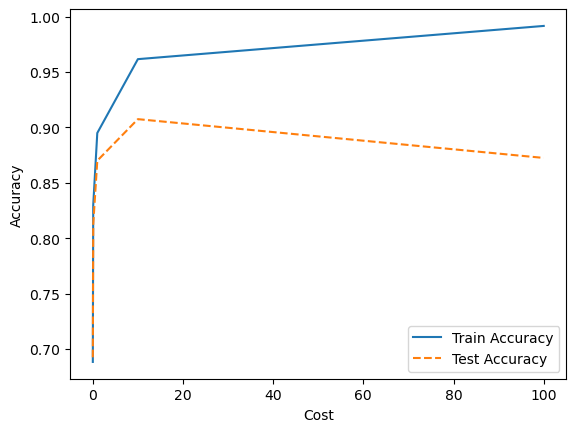

In [8]:
# 정확도 그래프 확인
plt.plot(para_c, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_c, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Cost")
plt.legend()

#### C= 10

In [9]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []

# para_c = [10 **c for c in range(-2, 3)] # 0.01, 0.1, 1, 10, 100 : 큰 변화 영향 확인
para_c = [0.1 * c for c in range(1, 100)] # 0.1~1.0 : 작은 변화 영향 확인

for v_C in para_c:
    svm = SVC(C = v_C, random_state = 1986, probability=True)
    svm.fit(df_train_x, df_train_y)
    train_accuracy.append(svm.score(df_train_x, df_train_y))
    test_accuracy.append(svm.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_c = pd.DataFrame()
df_accuracy_c["Cost"] = para_c
df_accuracy_c["TrainAccuracy"] = train_accuracy
df_accuracy_c["TestAccuracy"] = test_accuracy
df_accuracy_c.round(3)

,Cost,TrainAccuracy,TestAccuracy
0,0.1,0.830,0.812
1,0.2,0.847,0.830
2,0.3,0.858,0.838
3,0.4,0.863,0.832
4,0.5,0.868,0.845
...,...,...,...
94,9.5,0.958,0.908
95,9.6,0.958,0.908
96,9.7,0.960,0.908
97,9.8,0.962,0.910


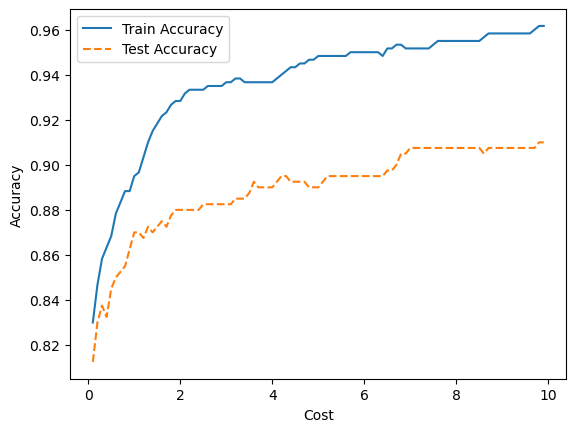

In [10]:
# 정확도 그래프 확인
plt.plot(para_c, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_c, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Cost")
plt.legend()

#### C= 5

In [11]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []

para_gamma = [10 **gamma for gamma in range(-2, 3)]   # 0.01, 0.1, 1, 10, 100 : 큰 변화 영향 확인
# para_gamma = [0.1 * gamma for gamma in range(1, 11)]     # 0.1~1.0 : 작은 변화 영향 확인

for v_gamma in para_gamma:
    svm = SVC(gamma = v_gamma, C = 5, random_state = 1986, probability=True)
    svm.fit(df_train_x, df_train_y)
    train_accuracy.append(svm.score(df_train_x, df_train_y))
    test_accuracy.append(svm.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_gamma = pd.DataFrame()
df_accuracy_gamma["gamma"] = para_gamma
df_accuracy_gamma["TrainAccuracy"] = train_accuracy
df_accuracy_gamma["TestAccuracy"] = test_accuracy
df_accuracy_gamma.round(4)

,gamma,TrainAccuracy,TestAccuracy
0,0.01,0.8967,0.8625
1,0.10,0.9683,0.9050
2,1.00,1.0000,0.7550
3,10.00,1.0000,0.7050
4,100.00,1.0000,0.6950


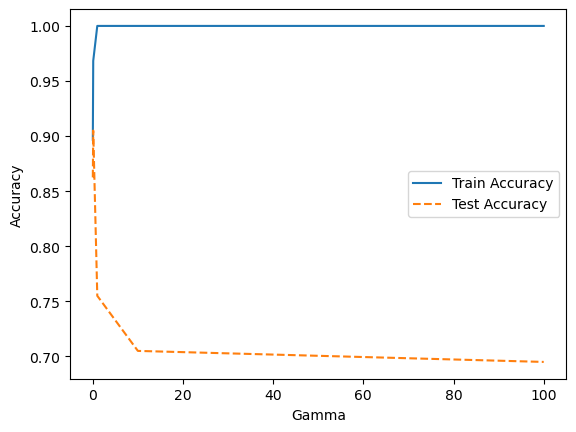

In [12]:
# 모델 정확도 그래프 확인
plt.plot(para_gamma, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_gamma, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Gamma")  # X 축 범위 log 변환
plt.legend()

In [13]:
# Gamma 미세 변화에 따른 모델 성능
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []

# para_gamma = [10 **gamma for gamma in range(-2, 3)]   # 0.01, 0.1, 1, 10, 100 : 큰 변화 영향 확인
para_gamma = [0.1 * gamma for gamma in range(1, 5)]     # 0.1~1.0 : 작은 변화 영향 확인

for v_gamma in para_gamma:
    svm = SVC(gamma = v_gamma, C = 5, random_state = 1986, probability=True)
    svm.fit(df_train_x, df_train_y)
    train_accuracy.append(svm.score(df_train_x, df_train_y))
    test_accuracy.append(svm.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_gamma = pd.DataFrame()
df_accuracy_gamma["gamma"] = para_gamma
df_accuracy_gamma["TrainAccuracy"] = train_accuracy
df_accuracy_gamma["TestAccuracy"] = test_accuracy
df_accuracy_gamma.round(4)

,gamma,TrainAccuracy,TestAccuracy
0,0.1,0.9683,0.9050
1,0.2,0.9883,0.8775
2,0.3,0.9917,0.8575
3,0.4,0.9967,0.8625


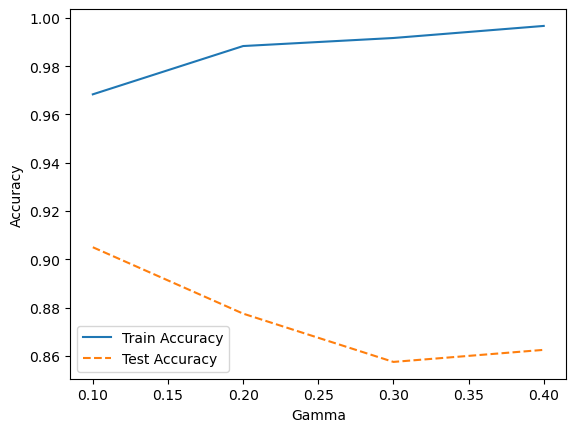

In [14]:
# 모델 정확도 그래프 확인
plt.plot(para_gamma, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_gamma, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Gamma")  # X 축 범위 log 변환
plt.legend()

In [15]:
# 최종 모델
svc_final = SVC(gamma=0.1, C=5, random_state=1986, probability=True)
svc_final.fit(df_train_x, df_train_y)

# 평가
y_pred_train = svc_final.predict(df_train_x)
y_proba_train = svc_final.predict_proba(df_train_x)[:, 1]
y_pred_test = svc_final.predict(df_test_x)
y_proba_test = svc_final.predict_proba(df_test_x)[:, 1]

# train 모델 정확도
print("Train Accucary : {:.3f}".format(svc_final.score(df_train_x, df_train_y)))
# test 모델 정확도
print("Test Accuracy : {:.3f}\n".format(svc_final.score(df_test_x, df_test_y)))
# confusion matrix
print("Test Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred_test)))

# 목표변수의 빈도 불균형 : f1 score로 모델 평가 
print(classification_report(df_test_y, y_pred_test, digits=3))

Train Accucary : 0.968
Test Accuracy : 0.905

Test Confusion matrix: 
[[267  10]
 [ 28  95]]
              precision    recall  f1-score   support

           0      0.905     0.964     0.934       277
           1      0.905     0.772     0.833       123

    accuracy                          0.905       400
   macro avg      0.905     0.868     0.883       400
weighted avg      0.905     0.905     0.903       400



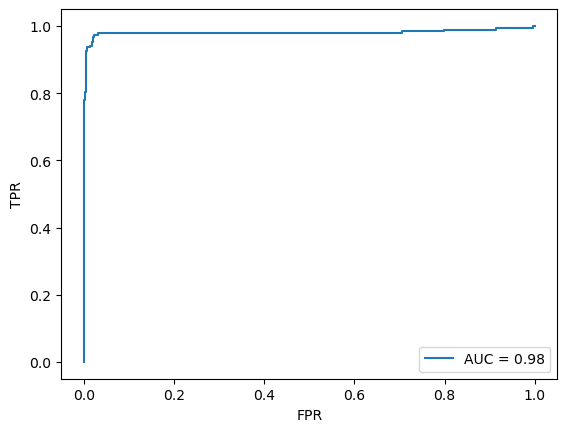

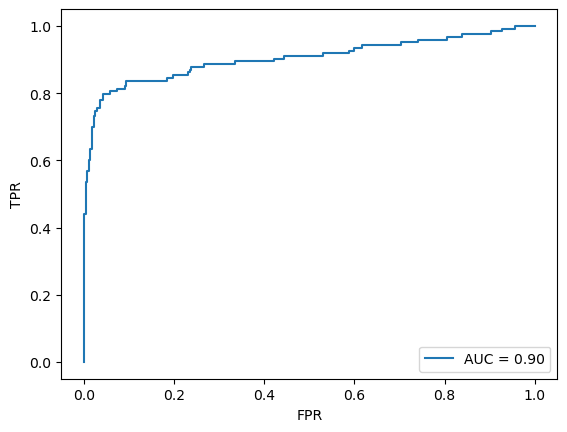

             SVM-train  SVM-test
Accuracy      0.968333  0.905000
Precision     0.988372  0.904762
Recall        0.909091  0.772358
F1_score      0.947075  0.833333
Specificity   0.995157  0.963899


In [17]:
def print_metric(y_true, y_pred, y_pred_proba, data_name): # 실제값, 예측값, ROC 커브이미지 저장이름 ex)RF-train
    cm = confusion_matrix(y_true, y_pred)
    TP = cm[1][1]
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1_score = 2 * (precision * recall) / (precision + recall)
    specificity = TN / (TN + FP)

    metric_list = [accuracy, precision,recall, f1_score, specificity]
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label= "AUC = %0.2f"% roc_auc)
    plt.legend(loc="lower right")
    plt.ylabel("TPR"); plt.xlabel("FPR") 
    plt.savefig(data_name+"_roc_curve.png")
    plt.show()
    
    return pd.DataFrame(metric_list, index=['Accuracy', 'Precision', 'Recall', 'F1_score', 'Specificity'])
metric_df_first = pd.DataFrame()
metric_list_train = print_metric(df_train_y, y_pred_train,y_proba_train, "SVM-train")
metric_list_test = print_metric(df_test_y, y_pred_test, y_proba_test, "SVM-test")

metric_df_first['SVM-train'] = metric_list_train
metric_df_first['SVM-test'] = metric_list_test

print(metric_df_first)    

# 2차모델

In [18]:
filepath = "./B1_종합실습2_전처리데이터(2차_svm_nn).csv"
df_raw = pd.read_csv(filepath, encoding='utf-8')

In [19]:
df_raw_x = df_raw.drop("scale", axis = 1, inplace = False)
df_raw_y = df_raw["scale"] 

df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y
                                    , test_size = 0.4, random_state = 1986)

nn_uncust = SVC(random_state=1986)
nn_uncust.fit(df_train_x, df_train_y)

# train 모델 정확도
print("Train Accuracy: {:.3f}".format(nn_uncust.score(df_train_x, df_train_y)))
# test 모델 정확도
print("Test Accuracy: {:.3f}".format(nn_uncust.score(df_test_x, df_test_y)))

Train Accuracy: 0.885
Test Accuracy: 0.835


In [20]:
# 최종 모델
svc_final = SVC(gamma=0.1, C=5, random_state=1986, probability=True)
svc_final.fit(df_train_x, df_train_y)

# 평가
y_pred_train = svc_final.predict(df_train_x)
y_proba_train = svc_final.predict_proba(df_train_x)[:, 1]
y_pred_test = svc_final.predict(df_test_x)
y_proba_test = svc_final.predict_proba(df_test_x)[:, 1]

# train 모델 정확도
print("Train Accucary : {:.3f}".format(svc_final.score(df_train_x, df_train_y)))
# test 모델 정확도
print("Test Accuracy : {:.3f}\n".format(svc_final.score(df_test_x, df_test_y)))
# confusion matrix
print("Test Confusion Matrix: \n{}".format(confusion_matrix(df_test_y, y_pred_test)))

# 목표변수의 빈도 불균형 : f1 score로 모델 평가 
print(classification_report(df_test_y, y_pred_test, digits=3))

Train Accucary : 0.922
Test Accuracy : 0.848

Test Confusion Matrix: 
[[258  19]
 [ 42  81]]
              precision    recall  f1-score   support

           0      0.860     0.931     0.894       277
           1      0.810     0.659     0.726       123

    accuracy                          0.848       400
   macro avg      0.835     0.795     0.810       400
weighted avg      0.845     0.848     0.843       400



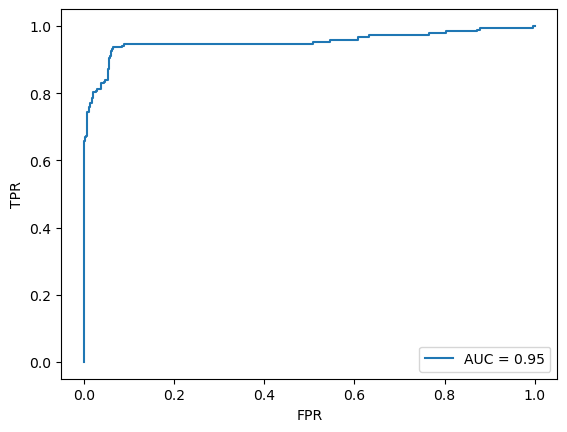

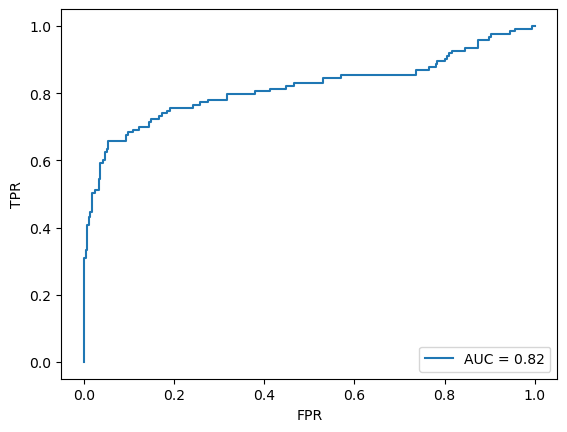

             SVM-train  SVM-test
Accuracy      0.921667  0.847500
Precision     0.948718  0.810000
Recall        0.791444  0.658537
F1_score      0.862974  0.726457
Specificity   0.980630  0.931408


In [21]:
from sklearn.metrics import roc_curve, auc
metric_df_second = pd.DataFrame()
metric_list_train = print_metric(df_train_y, y_pred_train,y_proba_train, "SVM-train")
metric_list_test = print_metric(df_test_y, y_pred_test, y_proba_test, "SVM-test")

metric_df_second['SVM-train'] = metric_list_train
metric_df_second['SVM-test'] = metric_list_test

print(metric_df_second)

In [22]:
metric_df_first['diff'] = metric_df_first['SVM-train'] - metric_df_first['SVM-test']
metric_df_second['diff'] = metric_df_second['SVM-train'] - metric_df_second['SVM-test']

print("1차 모델")
display(metric_df_first)
print("2차 모델")
display(metric_df_second)

1차 모델


,SVM-train,SVM-test,diff
Accuracy,0.968333,0.905000,0.063333
Precision,0.988372,0.904762,0.083610
Recall,0.909091,0.772358,0.136733
F1_score,0.947075,0.833333,0.113742
Specificity,0.995157,0.963899,0.031258


2차 모델


,SVM-train,SVM-test,diff
Accuracy,0.921667,0.847500,0.074167
Precision,0.948718,0.810000,0.138718
Recall,0.791444,0.658537,0.132907
F1_score,0.862974,0.726457,0.136516
Specificity,0.980630,0.931408,0.049222
